Pandas DataFrame을 이용하여 실제 데이터를 로드, 조작, 분석합니다.

**📋 상세 지시사항:**

1. **DataFrame 생성 및 기본 정보 확인**
   - 딕셔너리로부터 DataFrame 생성 (8명의 직원 데이터)
   - 속성: 이름, 나이, 도시, 급여, 부서, 경력
   - `df.info()`, `df.describe()` 사용하여 데이터 개요 파악

2. **단일 조건 필터링**
   - 나이가 30 이상인 직원 추출
   - 특정 도시(예: 서울) 거주 직원 찾기
   - 급여가 4000 이상인 직원 필터링

3. **복합 조건 필터링**
   - AND 연산: 서울 거주 **AND** 급여 4000 이상
   - OR 연산: 개발팀 **OR** 급여 4500 이상
   - NOT 연산: 개발팀이 아닌 직원

4. **기본 통계 및 집계**
   - 부서별 평균 급여 계산
   - 도시별 직원 수
   - 경력 통계 분석

In [ ]:
import pandas as pd
data = {
        'name': ['김철수', '이영희', '박민수', '최지영', '정태현', '한소희', '윤상호', '배수진'],
        'age': [25, 30, 35, 28, 42, 31, 29, 27],
        'city': ['서울', '부산', '대구', '서울', '광주', '서울', '부산', '대구'],
        'salary': [3500, 4200, 3800, 4500, 5200, 3900, 3600, 4100],
        'department': ['개발', '마케팅', '개발', '기획', '개발', '마케팅', '기획', '개발'],
        'experience': [2, 5, 8, 3, 12, 6, 4, 3]
    }

df = pd.DataFrame(data)
df.shape
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

(8, 6)

In [106]:
df.head()

,name,age,city,salary,department,experience
0,김철수,25,서울,3500,개발,2
1,이영희,30,부산,4200,마케팅,5
2,박민수,35,대구,3800,개발,8
3,최지영,28,서울,4500,기획,3
4,정태현,42,광주,5200,개발,12


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        8 non-null      str  
 1   age         8 non-null      int64
 2   city        8 non-null      str  
 3   salary      8 non-null      int64
 4   department  8 non-null      str  
 5   experience  8 non-null      int64
dtypes: int64(3), str(3)
memory usage: 516.0 bytes


In [108]:
df.describe()

,age,salary,experience
count,8.000000,8.00000,8.000000
mean,30.875000,4100.00000,5.375000
std,5.383507,550.32458,3.292307
min,25.000000,3500.00000,2.000000
25%,27.750000,3750.00000,3.000000
50%,29.500000,4000.00000,4.500000
75%,32.000000,4275.00000,6.500000
max,42.000000,5200.00000,12.000000


In [109]:
df['city'].value_counts()

city
서울    3
부산    2
대구    2
광주    1
Name: count, dtype: int64

In [110]:
df1 = df[df['age'] >= 30]
df1
# df = df[df['city'] == '서울']
# df = df[df['salary'] >= 4000]

,name,age,city,salary,department,experience
1,이영희,30,부산,4200,마케팅,5
2,박민수,35,대구,3800,개발,8
4,정태현,42,광주,5200,개발,12
5,한소희,31,서울,3900,마케팅,6


In [111]:
df2 = df[df['city'] == '서울']
df2

,name,age,city,salary,department,experience
0,김철수,25,서울,3500,개발,2
3,최지영,28,서울,4500,기획,3
5,한소희,31,서울,3900,마케팅,6


In [112]:
df3 = df[df['salary'] >= 4000]
df3

,name,age,city,salary,department,experience
1,이영희,30,부산,4200,마케팅,5
3,최지영,28,서울,4500,기획,3
4,정태현,42,광주,5200,개발,12
7,배수진,27,대구,4100,개발,3


In [113]:
cond1 = df['city'] == '서울'
cond2 = df['salary'] >= 4000
df4 = df[cond1 & cond2]
df4

,name,age,city,salary,department,experience
3,최지영,28,서울,4500,기획,3


In [114]:
cond3 = df['department'] == '개발'
cond4 = df['salary'] >= 4000

df5 = df[cond3 | cond4]
df5

,name,age,city,salary,department,experience
0,김철수,25,서울,3500,개발,2
1,이영희,30,부산,4200,마케팅,5
2,박민수,35,대구,3800,개발,8
3,최지영,28,서울,4500,기획,3
4,정태현,42,광주,5200,개발,12
7,배수진,27,대구,4100,개발,3


In [115]:
df6 = df.groupby('department')['salary'].mean()
print(df6)

department
개발     4150.0
기획     4050.0
마케팅    4050.0
Name: salary, dtype: float64


In [116]:
df7 = df['city'].value_counts()
df7

city
서울    3
부산    2
대구    2
광주    1
Name: count, dtype: int64

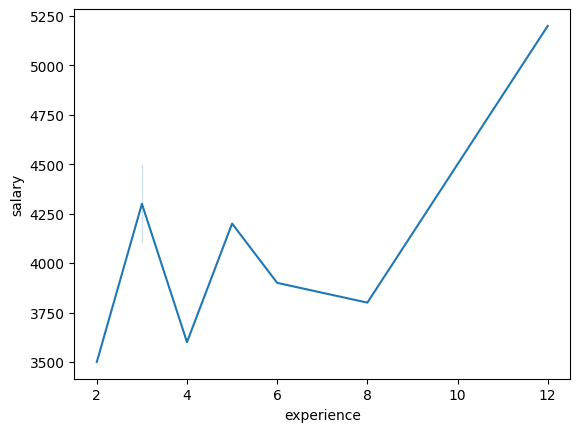

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data=df, x='experience', y='salary')
plt.show()

GroupBy를 사용하여 그룹별 집계 분석과 다중 조건 분석을 수행합니다.

**📋 상세 지시사항:**

1. **Titanic 데이터셋 이해**
   - seaborn 라이브러리로 titanic 데이터 로드: `sns.load_dataset('titanic')`
   - 데이터 형태: 891행, 15개 열
   - 주요 열: PassengerId, Survived, Pclass, Age, Sex, Fare, Embarked 등
   - 결측값 확인: Age(177개), Cabin(687개), Embarked(2개) 결측

2. **좌석 등급별 생존율 분석**
   - `groupby('pclass')['survived'].mean()` 사용
   - 예상 결과: 1등석 > 2등석 > 3등석 생존율
   - 생존율 차이 해석

3. **성별-좌석등급별 다중 집계**
   - `groupby(['sex', 'pclass']).agg()` 사용
   - 각 그룹별 나이 평균, 요금 최대값, 생존율 계산
   - 가장 높은 생존율 그룹 찾기

4. **피벗 테이블 생성**
   - 성별 × 좌석등급 생존율 피벗 테이블
   - 히트맵으로 시각화하여 패턴 확인

5. **시각화**
   - 좌석등급별 생존율 막대 그래프
   - 성별-좌석등급 생존율 히트맵
   - 연령대별 생존자 수

In [118]:
df = sns.load_dataset('titanic')
df.shape

(891, 15)

In [119]:
df1 = df.groupby('pclass')['survived'].mean()
df1

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [123]:
df2 = df.groupby(['sex', 'pclass']).agg({'age':['mean'], 'fare': ['max'], 'survived': ['mean']})
df2

age      fare  survived
                    mean       max      mean
sex    pclass                               
female 1       34.611765  512.3292  0.968085
       2       28.722973   65.0000  0.921053
       3       21.750000   69.5500  0.500000
male   1       41.281386  512.3292  0.368852
       2       30.740707   73.5000  0.157407
       3       26.507589   69.5500  0.135447

In [126]:
df3 = df.pivot_table(index='sex', columns='pclass', values='survived', aggfunc='mean')
df3

pclass,1,2,3
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


<Axes: xlabel='pclass', ylabel='sex'>

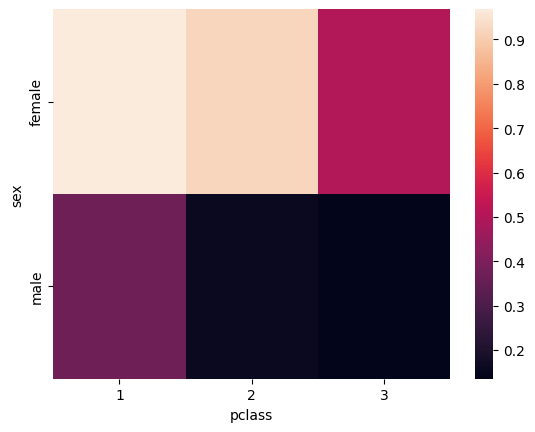

In [ ]:
sns.heatmap(
    data=df3
    )

<BarContainer object of 3 artists>

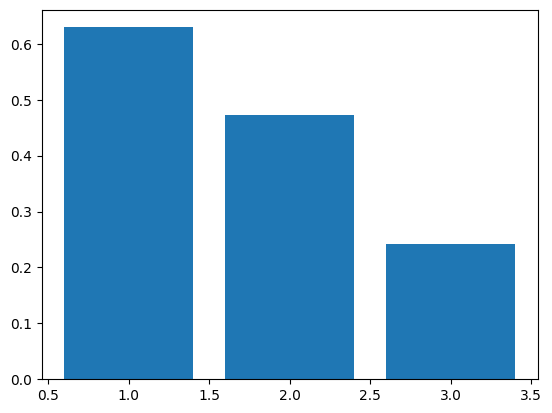

In [137]:
df4 = df.groupby('pclass')['survived'].mean().reset_index()
plt.bar(
    data=df4,
    x='pclass',
    height='survived'
)


<Axes: xlabel='pclass', ylabel='sex'>

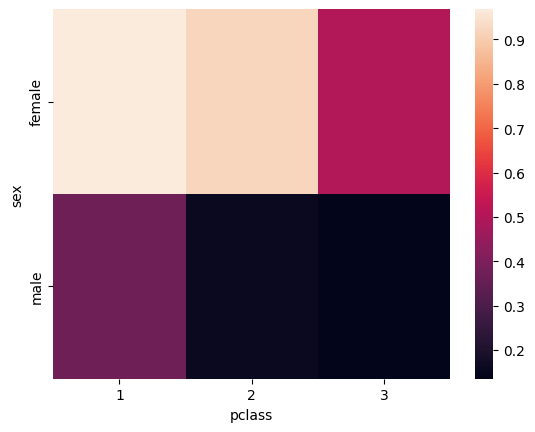

In [147]:
# df5 = df.groupby(['sex', 'pclass'])['survived'].mean()
df5 = df.pivot_table(index='sex', columns='pclass', values='survived', aggfunc='mean')

sns.heatmap(
    df5
)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_18796\3776726892.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='age_group', ylabel='survived'>

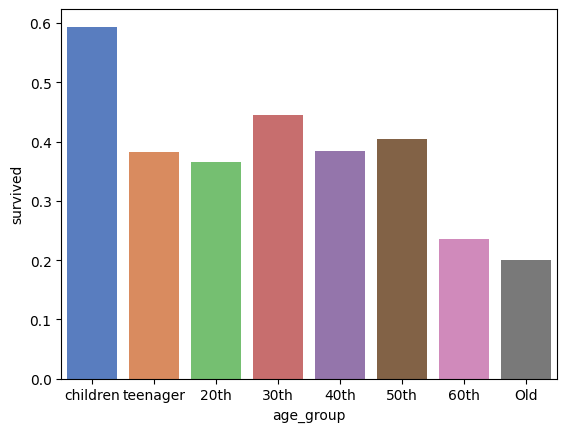

In [161]:


df['age_group'] = pd.cut(df['age'], 
                        bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], 
                        labels=['children', 'teenager', '20th', '30th', '40th', '50th', '60th', 'Old'])


df_group = df.groupby('age_group')['survived'].mean().reset_index()


sns.barplot(
    data=df_group, 
    x='age_group', 
    y='survived',
    palette='muted'
    )
